In [1]:
from collections import defaultdict

import pandas as pd
pd.options.display.float_format = '{:>5.2f}'.format
import numpy as np

import matplotlib.pyplot as plt
import json
from pprint import pprint

from scipy.ndimage.filters import gaussian_filter1d
from lifted_embedding_estimation_with_truth_value import name2lstr

In [2]:
metrics = ['mrr', 'hit1', 'hit3', 'hit10']

Conjunction_queries = ['1p', '2p', '3p', '2i', '3i', 'ip', 'pi']
Negation_queries = ['2in', '3in', 'inp', 'pin', 'pni']
Disjunction_queries = ['2u', 'up', '2u-dm', 'up-dm']
queries = Conjunction_queries + Negation_queries + Disjunction_queries

filter_width = .1

In [3]:
def read_log_lines(filename):
    lines = []
    with open(filename, 'rt') as f:
        for line in f.readlines():
            lines.append(line)
    return lines

def filter_lines(lines, key_str):
    rec = []
    for line in lines:
        if not key_str in line:
            continue
        json_content = json.loads(line.split(']')[-1])
        try:
            rec.append(
                json_content
            )
        except:
            print("Error in ", line)
    return rec 

In [4]:
def plot_train_lines(lines, lstr=None):
    rec = filter_lines(lines=lines, key_str="learn")
    if not rec:
        return
    data = defaultdict(list)
    for i, this_record in enumerate(rec):
        for k in this_record:
            data[k].append(this_record[k])
        data['id'].append(i)
    df = pd.DataFrame(data)
    
    if lstr:
        df = df[df.lstr == lstr]
        
    if len(df) > 100000:
        df = df.sample(n=100000)

    fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(20, 6))

    ax1.set_xlabel('steps')
    ax1.set_ylabel('truth value')
    keys = ['pos_tv', 'neg_tv', 'lifted_tv']
    for label in keys:
        if label in df.columns:
            ax1.scatter(df['id'], df[label], s=0.1, label=label)
    # ax1.plot(df['id'], gaussian_filter1d(df['pos_tv'] - df['neg_tv'], filter_width), label='pos - neg', color='purple', alpha=0.5)
    ax1.axhline(y=0.5, color='r', linestyle='-')
    ax1.legend()
    ax1.set_ylim([0, 1])


    ax2.set_xlabel('steps')
    ax2.set_ylabel('loss')
    keys = ['loss', 'pos_nll', 'neg_nll', 'lifted_nll', 'contrastive_nll']
    for label in keys:
        if label in df:
            ax2.scatter(df['id'], df[label], s=0.1, label=label)
    ax2.legend()
    ax2.set_xlim(left=0)
    
    keys = ['pos_score', 'neg_score']
    for label in keys:
        if label in df:
            ax3.scatter(df['id'], df[label], s=0.1, label=label)
    ax3.legend()

    # ax2.set_yscale('log')
    # ax2.set_yticks([1e-2, 1e-1, 1])
    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    plt.show()


def plot_evaluation(scope=['train', 'validate', 'test']):
    all_rec = filter_lines(lines=lines, key_str="evaluate")

    
    for k in queries:        
        if not any(k in rec for rec in all_rec): continue
        fig, axes = plt.subplots(ncols=len(scope), figsize=(3 * len(scope) + 1, 3))
        
        if len(scope) == 1:
            axes = [axes]

        for ax, desc in zip(axes, scope):
            rec = filter_lines(lines=lines, key_str=f"evaluate {desc}")
            if not rec: continue
            if k not in rec[0]: continue

            data = defaultdict(list)
            for i, this_record in enumerate(rec):
                for k1 in this_record[k]:
                    data[k1].append(this_record[k][k1])
                data['id'].append(i)

            df = pd.DataFrame(data)

            ax.set_xlabel('epoch')
            ax.set_ylabel('score')
            ax.set_title(f'{desc} scores for query {k}')

            for label in metrics:
                if len(df['id']) == 1:
                    ax.scatter(df['id'], df[label] * 100, label=label)
                else:
                    ax.plot(df['id'], df[label] * 100, label=label)
            ax.legend()
            # ax.set_ylim([0, 1])

        fig.tight_layout()  # otherwise the right y-label is slightly clipped
        plt.show()

In [5]:
def evaluation_to_tables(line, collect_metrics=metrics, verbose=True):
    data = defaultdict(list)
    for m in collect_metrics:
        data['metric'].append(m)
        for k in queries:
            if k in line:
                data[k].append(line[k][m] * 100)
    df = pd.DataFrame(data)
    try:
        df['epfo mean'] = df[Conjunction_queries + Disjunction_queries].mean(axis=1)
    except:
        pass
    try:
        df['Neg mean'] = df[Negation_queries].mean(axis=1)
    except:
        pass
    return df

def aggregate_evaluations(lines, key_str, collect_metrics=metrics):
    print(key_str)
    rec_lines = filter_lines(lines, key_str)
    df_list = []
    for e, line in enumerate(rec_lines):
        df = evaluation_to_tables(line, collect_metrics)
        # print(df.to_markdown(floatfmt=".2f"))
        df['epoch'] = e
        df_list.append(df)
    if len(df_list) == 0:
        return
    final_df = pd.concat(df_list)
    final_df = final_df.set_index(['epoch', 'metric'])
    print(final_df.to_markdown(floatfmt=".1f"))

/tmp/ipykernel_11332/748659763.py:49: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()  # otherwise the right y-label is slightly clipped
/home/zwanggc/anaconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


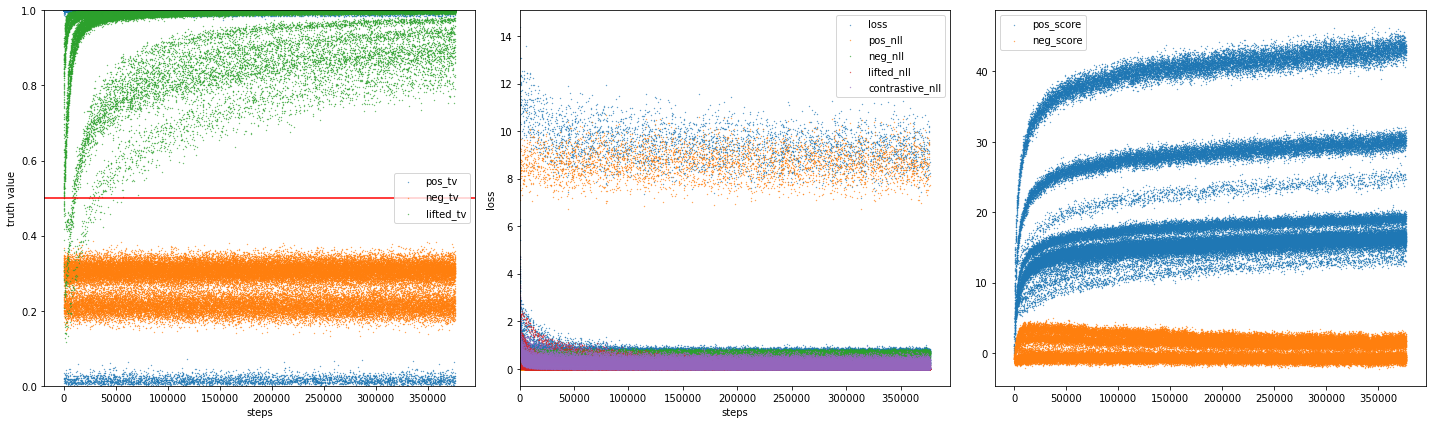

CQD evaluate valid
|             |   1p |   2p |   3p |   2i |   3i |   ip |   pi |   2in |   3in |   inp |   pin |   pni |   2u |   up |   2u-dm |   up-dm |   epfo mean |   Neg mean |
|:------------|-----:|-----:|-----:|-----:|-----:|-----:|-----:|------:|------:|------:|------:|------:|-----:|-----:|--------:|--------:|------------:|-----------:|
| (0, 'mrr')  | 44.6 |  4.9 |  2.9 | 16.2 | 20.6 |  5.8 |  4.4 |   0.0 |   0.0 |   0.3 |   0.1 |   0.0 | 11.3 |  4.8 |    11.3 |     0.1 |        11.5 |        0.1 |
| (1, 'mrr')  | 44.6 |  5.1 |  3.3 | 16.2 | 20.6 |  6.3 |  4.8 |   0.0 |   0.0 |   0.3 |   0.1 |   0.0 | 11.3 |  4.8 |    11.3 |     0.1 |        11.7 |        0.1 |
| (2, 'mrr')  | 44.6 |  5.2 |  3.5 | 16.2 | 20.6 |  6.6 |  4.8 |   0.0 |   0.0 |   0.3 |   0.0 |   0.0 | 11.3 |  4.8 |    11.3 |     0.1 |        11.7 |        0.1 |
| (3, 'mrr')  | 44.6 |  5.2 |  3.6 | 16.2 | 20.6 |  6.7 |  5.0 |   0.0 |   0.0 |   0.3 |   0.0 |   0.0 | 11.3 |  4.8 |    11.3 |     0.1 |        11.8 

In [6]:
lines = read_log_lines('log/train_GNN_reasoner_betae_margin=05/output.log')
plot_train_lines(lines)
aggregate_evaluations(lines, 'CQD evaluate valid', collect_metrics=['mrr'])
aggregate_evaluations(lines, 'NN evaluate valid', collect_metrics=['mrr'])

aggregate_evaluations(lines, 'CQD evaluate test', collect_metrics=['mrr'])
aggregate_evaluations(lines, 'NN evaluate test', collect_metrics=['mrr'])

/tmp/ipykernel_11332/748659763.py:49: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()  # otherwise the right y-label is slightly clipped


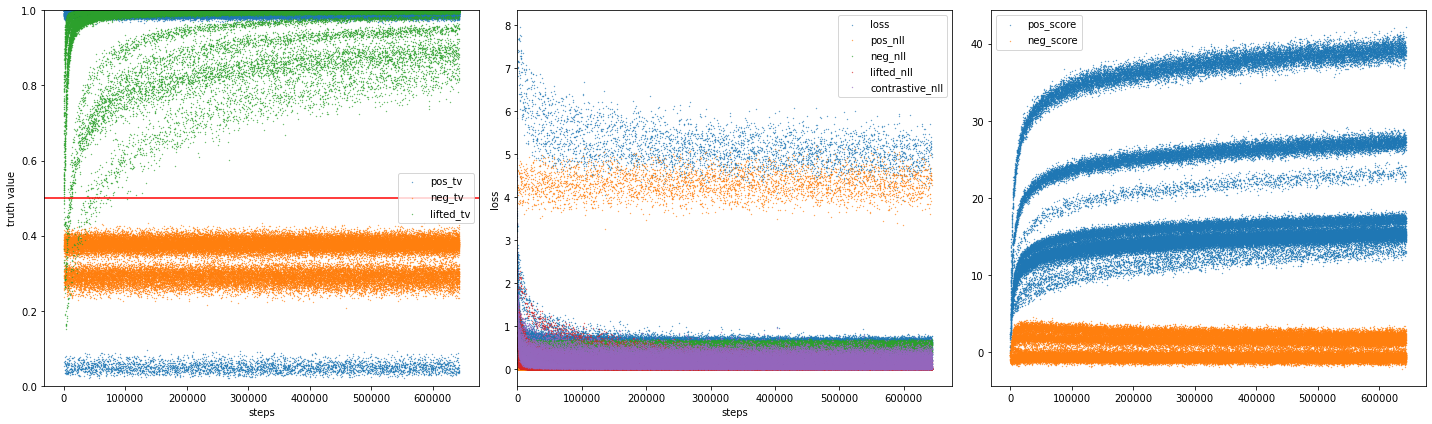

CQD evaluate valid
|             |   1p |   2p |   3p |   2i |   3i |   ip |   pi |   2in |   3in |   inp |   pin |   pni |   2u |   up |   2u-dm |   up-dm |   epfo mean |   Neg mean |
|:------------|-----:|-----:|-----:|-----:|-----:|-----:|-----:|------:|------:|------:|------:|------:|-----:|-----:|--------:|--------:|------------:|-----------:|
| (0, 'mrr')  | 44.7 |  5.8 |  3.7 | 16.1 | 20.5 |  6.1 |  5.1 |   0.0 |   0.0 |   0.3 |   0.1 |   0.0 | 11.3 |  5.1 |    11.3 |     0.1 |        11.8 |        0.1 |
| (1, 'mrr')  | 44.7 |  6.0 |  4.0 | 16.1 | 20.5 |  6.6 |  5.6 |   0.0 |   0.0 |   0.3 |   0.1 |   0.0 | 11.3 |  5.3 |    11.3 |     0.1 |        12.0 |        0.1 |
| (2, 'mrr')  | 44.7 |  6.1 |  4.1 | 16.1 | 20.5 |  6.9 |  5.8 |   0.0 |   0.0 |   0.2 |   0.1 |   0.0 | 11.3 |  5.3 |    11.3 |     0.1 |        12.0 |        0.1 |
| (3, 'mrr')  | 44.7 |  6.2 |  4.2 | 16.1 | 20.5 |  7.0 |  5.9 |   0.0 |   0.0 |   0.3 |   0.0 |   0.0 | 11.3 |  5.3 |    11.3 |     0.1 |        12.1 

In [7]:
lines = read_log_lines('log/train_GNN_reasoner_betae/output.log')
plot_train_lines(lines)
aggregate_evaluations(lines, 'CQD evaluate valid', collect_metrics=['mrr'])
aggregate_evaluations(lines, 'NN evaluate valid', collect_metrics=['mrr'])

aggregate_evaluations(lines, 'CQD evaluate test', collect_metrics=['mrr'])
aggregate_evaluations(lines, 'NN evaluate test', collect_metrics=['mrr'])

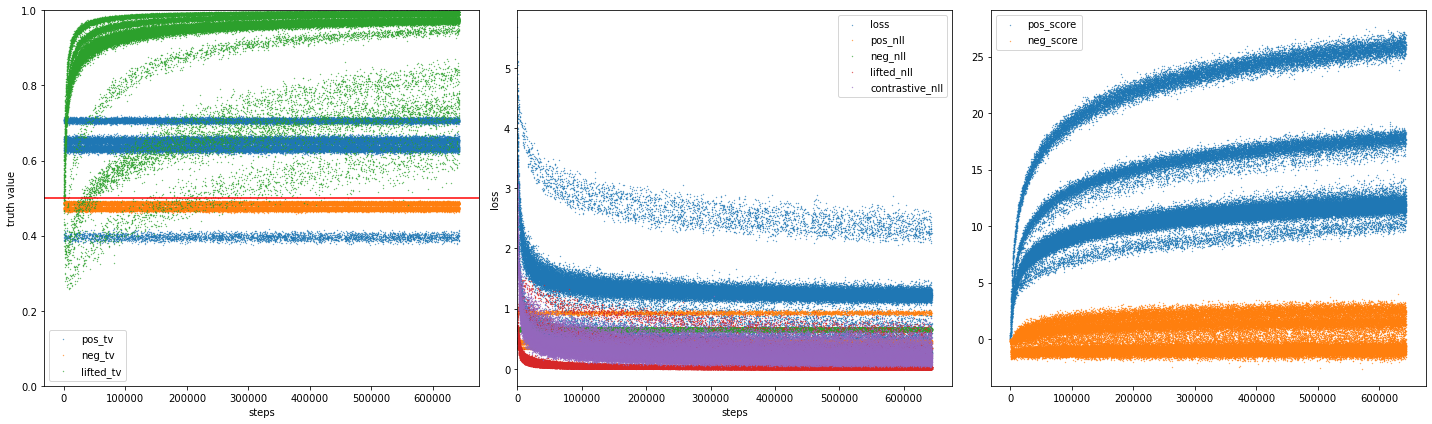

CQD evaluate valid
|             |   1p |   2p |   3p |   2i |   3i |   ip |   pi |   2in |   3in |   inp |   pin |   pni |   2u |   up |   2u-dm |   up-dm |   epfo mean |   Neg mean |
|:------------|-----:|-----:|-----:|-----:|-----:|-----:|-----:|------:|------:|------:|------:|------:|-----:|-----:|--------:|--------:|------------:|-----------:|
| (0, 'mrr')  | 44.7 |  5.9 |  3.9 | 16.1 | 20.5 |  5.6 | 11.1 |   0.0 |   0.0 |   0.3 |   0.1 |   0.1 | 11.3 |  5.4 |    11.3 |     0.0 |        12.4 |        0.1 |
| (1, 'mrr')  | 44.7 |  6.2 |  4.2 | 16.1 | 20.5 |  5.9 | 12.6 |   0.0 |   0.0 |   0.2 |   0.1 |   0.1 | 11.3 |  5.5 |    11.3 |     0.0 |        12.6 |        0.1 |
| (2, 'mrr')  | 44.7 |  6.3 |  4.2 | 16.1 | 20.5 |  6.1 | 13.3 |   0.0 |   0.0 |   0.2 |   0.0 |   0.1 | 11.3 |  5.5 |    11.3 |     0.1 |        12.7 |        0.1 |
| (3, 'mrr')  | 44.7 |  6.3 |  4.2 | 16.1 | 20.5 |  6.1 | 13.8 |   0.0 |   0.0 |   0.2 |   0.0 |   0.2 | 11.3 |  5.5 |    11.3 |     0.1 |        12.7 

In [8]:
lines = read_log_lines('log/train_GNN_reasoner_betae_margin=10/output.log')
plot_train_lines(lines)
aggregate_evaluations(lines, 'CQD evaluate valid', collect_metrics=['mrr'])
aggregate_evaluations(lines, 'NN evaluate valid', collect_metrics=['mrr'])

aggregate_evaluations(lines, 'CQD evaluate test', collect_metrics=['mrr'])
aggregate_evaluations(lines, 'NN evaluate test', collect_metrics=['mrr'])

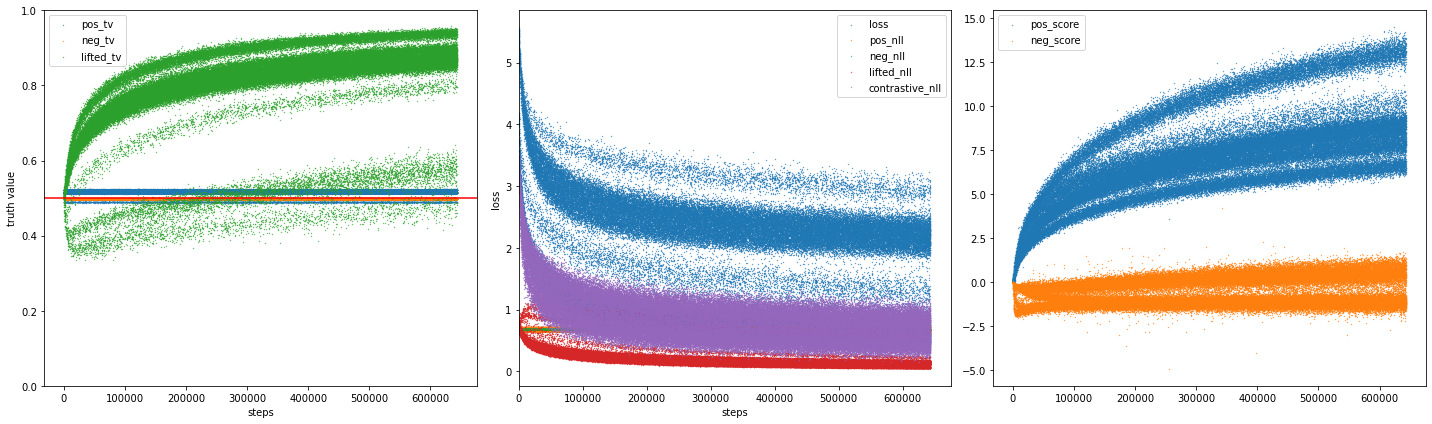

CQD evaluate valid
|             |   1p |   2p |   3p |   2i |   3i |   ip |   pi |   2in |   3in |   inp |   pin |   pni |   2u |   up |   2u-dm |   up-dm |   epfo mean |   Neg mean |
|:------------|-----:|-----:|-----:|-----:|-----:|-----:|-----:|------:|------:|------:|------:|------:|-----:|-----:|--------:|--------:|------------:|-----------:|
| (0, 'mrr')  | 44.7 |  4.7 |  1.7 | 16.1 | 20.5 |  4.4 | 12.4 |   0.0 |   0.0 |   0.1 |   0.0 |   0.2 | 11.3 |  5.0 |    11.3 |     0.0 |        12.0 |        0.1 |
| (1, 'mrr')  | 44.7 |  4.9 |  2.0 | 16.1 | 20.5 |  4.6 | 14.1 |   0.0 |   0.0 |   0.1 |   0.1 |   0.3 | 11.3 |  5.2 |    11.3 |     0.0 |        12.3 |        0.1 |
| (2, 'mrr')  | 44.7 |  5.1 |  2.3 | 16.1 | 20.5 |  4.7 | 14.9 |   0.0 |   0.0 |   0.1 |   0.1 |   0.3 | 11.3 |  5.2 |    11.3 |     0.0 |        12.4 |        0.1 |
| (3, 'mrr')  | 44.7 |  5.2 |  2.5 | 16.1 | 20.5 |  4.8 | 15.3 |   0.0 |   0.0 |   0.2 |   0.1 |   0.3 | 11.3 |  5.3 |    11.3 |     0.0 |        12.5 

In [9]:
lines = read_log_lines('log/train_GNN_reasoner_betae_margin=100/output.log')
plot_train_lines(lines)
aggregate_evaluations(lines, 'CQD evaluate valid', collect_metrics=['mrr'])
aggregate_evaluations(lines, 'NN evaluate valid', collect_metrics=['mrr'])

aggregate_evaluations(lines, 'CQD evaluate test', collect_metrics=['mrr'])
aggregate_evaluations(lines, 'NN evaluate test', collect_metrics=['mrr'])